In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/telco_customer_churn_cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (7032, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-

In [4]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [5]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [6]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


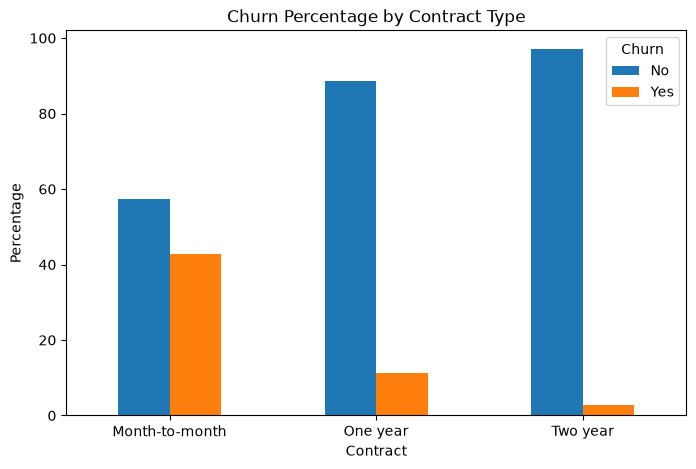

In [7]:
contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Percentage by Contract Type")

plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

In [8]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


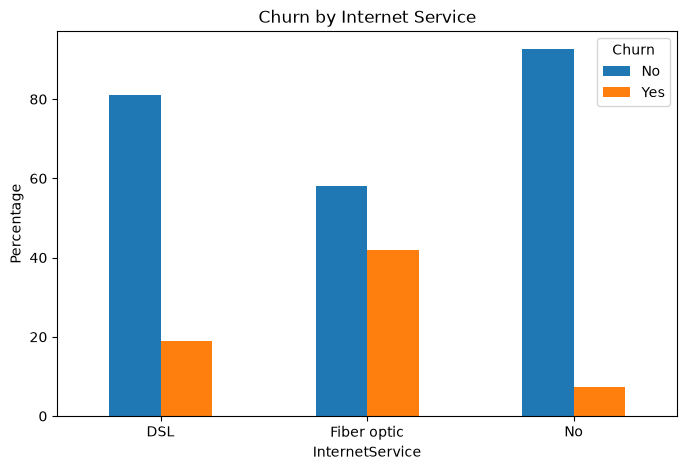

In [9]:
internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn by Internet Service")

plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

In [10]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


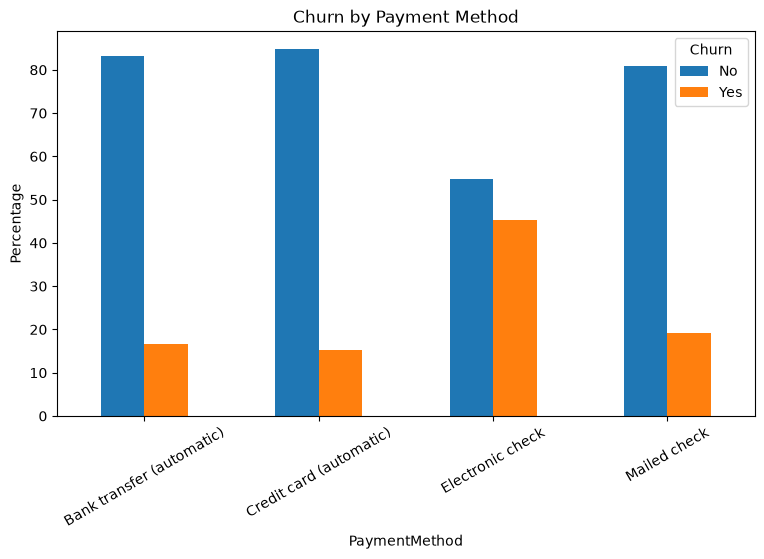

In [11]:
payment_churn.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Churn by Payment Method")

plt.ylabel("Percentage")

plt.xticks(rotation=30)

plt.show()

In [12]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


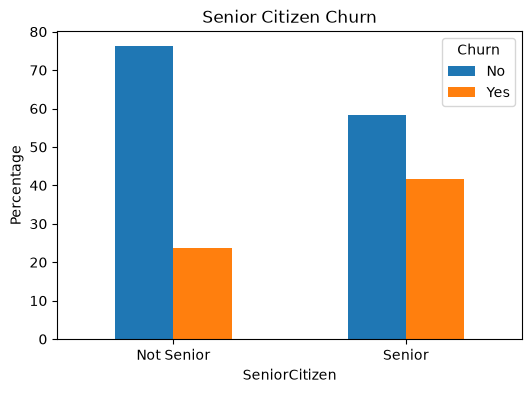

In [13]:
senior_churn.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Senior Citizen Churn")

plt.ylabel("Percentage")

plt.xticks(
    [0,1],
    ["Not Senior","Senior"],
    rotation=0
)

plt.show()

Final Business Recommendations

1. Promote long-term contracts through attractive discounts.

2. Improve Fiber Optic service quality and customer experience.

3. Encourage automatic payment methods.

4. Identify high-risk customers early using the churn prediction model.

5. Launch targeted retention campaigns before customers decide to leave.

Executive Summary

• Dataset Size: 7,032 customers

• Churn Rate: Approximately 27%

• Best Machine Learning Model:
  Logistic Regression

• Model Accuracy:
  Approximately 80%

Key Findings

• Month-to-Month contracts show the highest churn.

• Fiber Optic customers churn more frequently.

• Electronic Check users have higher churn rates.

• Longer customer tenure is associated with lower churn.

Business Impact

Deploying the churn prediction model enables the company to proactively identify customers at risk of leaving and implement targeted retention strategies, helping reduce revenue loss and improve customer satisfaction.